# 04 — The composite benchmark: three modes, no atmosphere

**Paper element.** Supplemental Material, Supplementary Limit Figures: figure
`05_composite_noatm`. The surfaces drawn here are also the family the Letter's
composite-dark-matter benchmark is recast from — the $f_\mathrm{DM}$ = 0.1,
$\lambda$ = 20 µm ($m_\phi \approx 10$ meV) slice — although the recast itself,
from $\alpha_n$ into a nucleon cross section $\sigma_{\chi n}$ at a 1 keV
constituent mass, is done by `scripts/paper_fig_limits.py` and not here.

**Two words that mean different things.** "Composite" in the figure name below
means the three **sensor modes** combined: a point is excluded if *any* mode
excludes it (element-wise max of the extremeness). The Letter's **composite dark
matter** benchmark is a physics model — a bound state of light constituents, in
a $(m_d, \sigma_{\chi n})$ parameterisation. They meet at one place only: the
benchmark is quoted on the $f_\mathrm{DM}$ = 0.1, 20 µm surface, which is one of
the slices this notebook draws. No quantity from the constituent model appears
here.

**What is switched off.** The counterpart to [`01`](01_the_limit.ipynb), with
overburden attenuation **off**: the DM velocity distribution is the bare
standard halo model for every $(m_{\rm DM}, \alpha_n)$ (no attenuation ODE), so
there is **no atmospheric ceiling** — exclusion runs up to $\alpha_n = 1$. Shown
per mediator range, at the same fiducials otherwise — $q_\text{min}$ = 1 TeV/$c$,
per-mode efficiency, candidates `data_mode{n}.txt`, $T$ = 219.66 h.

**Dark matter fraction.** This notebook opens **file B** of the release, which
carries exactly one hypothesis: $f_\mathrm{DM}$ = 0.1 with attenuation off.
Notebook 01, which draws the attenuated counterpart, opens file A at
$f_\mathrm{DM}$ = 1.

**The right-hand edge.** The impact-parameter integral is uncapped in this
release, so nothing in the surfaces closes the massless contour on the right; it
runs to the Planck mass. The release closes it with a halo flux cut — the mass
beyond which fewer than $N_\text{req} = 3$ particles pass within 10 cm of the
sensor during the exposure, **an assumption** stored in the file's `m_cut_*`
attributes and taken apart in [`03_the_edges.ipynb`](03_the_edges.ipynb). At
$f_\mathrm{DM}$ = 0.1 that is a factor of ten lower than in notebook 01:
$m_\text{cut} = 6.11\times10^{13}$ GeV. It is drawn below; nothing to its right
is a claim.

Surfaces: the atmosphere-off plane of the data release, selected with the
back-compatible `group='noatm'` spelling (in the current cube layout that is the
`atmosphere = 0` value of the `atmosphere` axis, not a separate group, and in
file B it is the only value on that axis); composite = element-wise max of the
three modes' extremeness.

In [1]:
%matplotlib inline
import os as _os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

from luhdm import release

for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)
def save_figure(fig, name, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number
    # prefix, stamped with the data-release version that produced it so
    # a figure always names its cube
    fig.text(0.995, 0.004, f"POLONAISE UHDM data release {rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)

MODES = (1, 2, 3)
CONF = 0.95
M_PLANCK = 1.22e19
G_PER_GEV = 1.78266192e-24   # 1 GeV/c^2 in grams

RANGES = ["massless", "2mm", "200um", "20um"]  # the physics slices; the axis
                                               # also holds a 200 m
                                               # convergence check, not drawn
LABEL = {"massless": "massless", "2m": "2 m", "2cm": "2 cm", "2mm": "2 mm",
         "200um": "200 µm", "20um": "20 µm", "10um": "10 µm", "2um": "2 µm"}
STYLE = {"massless": "solid", "2m": (0, (5, 1)), "2cm": (0, (1, 1)),
         "2mm": (0, (3, 5, 1, 5)), "200um": (0, (5, 5)), "20um": (0, (3, 1, 1, 1)),
         "10um": (0, (1, 3)), "2um": (0, (3, 5, 1, 5, 1, 5))}
# colour ramp over ranges (long range dark -> short range light), viridis
RCOLOR = {t: plt.cm.viridis(x) for t, x in zip(RANGES, np.linspace(0.05, 0.85, len(RANGES)))}

# File B of the released pair: f_DM = 0.1 with attenuation OFF, which is this
# notebook's whole subject. Its companion, file A, is luhdm.release.DEFAULT_PATH
# and the --release default of the paper-figure scripts.
rel = release.open_release("../release/luhdm_datarelease_v9p1_B_f0p1_noatm.h5")

# the halo flux cut that closes every contour on the right, read from the file
# rather than typed in: file B stores it at its own f_DM = 0.1.
M_CUT = next(float(v) for k, v in rel.attrs.items()
             if k.startswith("m_cut_") and k.endswith("_gev"))
N_REQ = float(rel.attrs["m_cut_n_transits_required"])

def composite(tag):
    """(ms, alphas, max-over-modes extremeness) for one range, from /noatm."""
    return (rel.axes_noatm.mass_gev, rel.axes.alpha_n,
            rel.composite("extremeness", lam=tag, group="noatm"))

## Status

In [2]:
for tag in RANGES:
    ms, al, ext = composite(tag)
    frac = f"{(ext >= CONF).mean():.3f}"
    # /noatm completeness: fraction of cells with a valid status (not exception=1)
    comp = " ".join(
        f"m{n}:{(rel.mass_plane('status', mode=n, lam=tag, group='noatm') != 1).mean():.2f}"
        for n in MODES)
    print(f"{tag:>9} | /noatm complete {comp} | composite excluded {frac}")
print(f"\nflux cut m_cut = {M_CUT:.3g} GeV at f_DM = {rel.f_dm_values[0]:g} "
      f"(N_req = {N_REQ:g} transits within {rel.attrs['m_cut_b_cap_m']:g} m -- "
      f"an assumption; see release/README.md section 5.4)")

 massless | /noatm complete m1:1.00 m2:1.00 m3:1.00 | composite excluded 0.537
      2mm | /noatm complete m1:1.00 m2:1.00 m3:1.00 | composite excluded 0.300
    200um | /noatm complete m1:1.00 m2:1.00 m3:1.00 | composite excluded 0.207
     20um | /noatm complete m1:1.00 m2:1.00 m3:1.00 | composite excluded 0.092

flux cut m_cut = 6.11e+13 GeV at f_DM = 0.1 (N_req = 3 transits within 0.1 m -- an assumption; see release/README.md section 5.4)


## Three-mode exclusion — no atmosphere

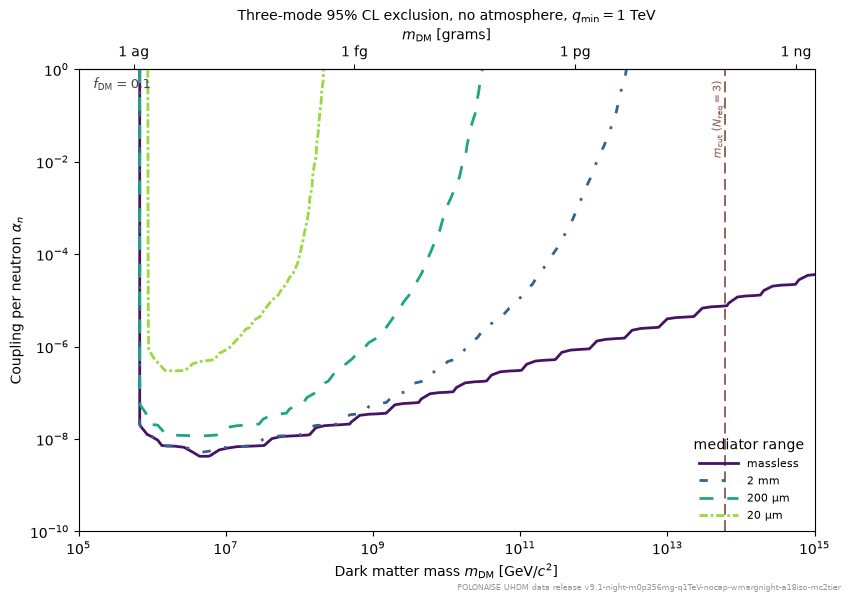

In [3]:
XMAX = 1e15   # past the flux cut; the massless contour itself does not close
fig, ax = plt.subplots(figsize=(8.5, 6))
xmin = M_PLANCK
drawn = []
for tag in RANGES:
    c = composite(tag)
    if c is None:
        continue
    ms, al, ext = c
    if not (ext >= CONF).any():
        continue
    xmin = min(xmin, ms.min())
    drawn.append(tag)
    ax.contour(ms, al, ext, levels=[CONF], colors=[RCOLOR[tag]],
               linestyles=[STYLE[tag]], linewidths=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(xmin, XMAX); ax.set_ylim(1e-10, 1.0)
ax.set_xlabel(r"Dark matter mass $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per neutron $\alpha_n$")
sec = ax.secondary_xaxis("top",
                         functions=(lambda x: x*G_PER_GEV, lambda g: g/G_PER_GEV))
sec.set_xlabel(r"$m_{\rm DM}$ [grams]")
_gt = [1e-18, 1e-15, 1e-12, 1e-9, 1e-6]; _gl = ["1 ag", "1 fg", "1 pg", "1 ng", "1 µg"]
_keep = [(t, l) for t, l in zip(_gt, _gl) if xmin*G_PER_GEV <= t <= XMAX*G_PER_GEV]
sec.set_xticks([t for t, _ in _keep]); sec.set_xticklabels([l for _, l in _keep])
sec.xaxis.set_minor_locator(plt.NullLocator())
ax.axvline(M_CUT, color="#8c564b", lw=1.3, ls=(0, (6, 3)), zorder=1)
ax.text(M_CUT, 0.985, r"$m_{\rm cut}$ ($N_{\rm req}=3$) ", color="#8c564b",
        fontsize=8, ha="right", va="top", rotation=90,
        transform=ax.get_xaxis_transform())
ax.set_title("Three-mode 95% CL exclusion, no atmosphere, $q_{\\rm min}=1$ TeV",
             fontsize=10)
# State the abundance plane in the figure: this scan reads the loader
# default f_DM = 0.1, not the f_DM = 1 the coupling limits are quoted at.
ax.text(0.02, 0.98, r"$f_{\rm DM}$ = 0.1", transform=ax.transAxes,
        ha="left", va="top", fontsize=9, color="#444444")
handles = [Line2D([], [], color=RCOLOR[t], lw=2, linestyle=STYLE[t], label=LABEL[t])
           for t in RANGES if t in drawn]
ax.legend(handles=handles, loc="lower right", frameon=False, fontsize=8,
          handlelength=3.5,
          title="mediator range")
fig.tight_layout(); save_figure(fig, "05_composite_noatm"); plt.show()

## The two released hypotheses, side by side

The release is two files and they are the two halves of the same campaign, so
they are worth seeing on one plane. **Read the difference carefully:** the two
files differ in *both* hypotheses at once — file A is $f_\mathrm{DM}$ = 1 with
attenuation applied, file B is $f_\mathrm{DM}$ = 0.1 with the bare halo — and
neither file carries the other's atmosphere setting at its own $f_\mathrm{DM}$.
Nothing below can therefore be read as "what the atmosphere costs" on its own.

What *can* be read off, and is the point of the pair:

- **The ceiling is the atmosphere's signature.** File A's band closes from above
  along part of the massless contour: at large coupling the overburden slows
  particles below threshold before they arrive. File B has no ceiling at all —
  its band runs to $\alpha_n = 1$ everywhere it is excluded, because nothing
  extinguishes it. That difference is the atmosphere and only the atmosphere.
- **The floor gap is mostly the flux normalisation.** Ten times less of this
  species means ten times fewer transits, so file B's floor sits above file A's
  by roughly the $\sqrt{10}$ the $\mu \propto \alpha_n^2 f_\mathrm{DM}$ scaling
  predicts, modulated by where the attenuated $f(v)$ has moved the spectrum.
- **The flux cut moves with $f_\mathrm{DM}$ exactly**, by the factor of ten it
  is linear in: $6.11\times10^{14}$ GeV against $6.11\times10^{13}$.

The cell prints the floor ratio against $\sqrt{10}$ so the second bullet is a
measurement rather than an assertion.

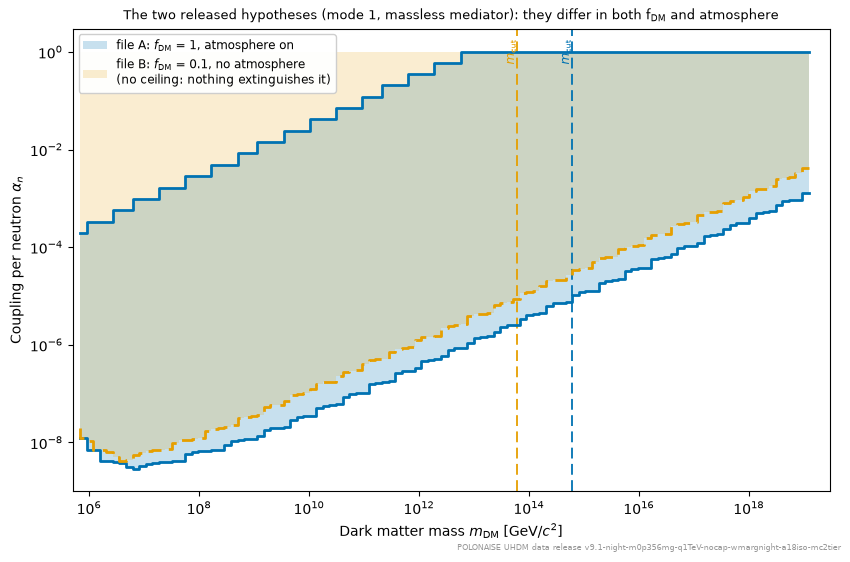

mode 1, massless: floor(file B) / floor(file A) over the 112 masses both exclude:
  median 2.99, range 1.00 .. 4.07;  sqrt(10) = 3.16
  masses with a ceiling below the top of the coupling grid: file A 59, file B 0
  m_cut: file A 6.111e+14 GeV, file B 6.111e+13 GeV (ratio 10.0)


In [4]:
relA = release.open_release("../release/luhdm_datarelease_v9p1_A_f1_atm.h5")
M_CUT_A = next(float(v) for k, v in relA.attrs.items()
               if k.startswith("m_cut_") and k.endswith("_gev"))

from luhdm import limits


def band(r, lam, f_dm, atmosphere, mode=1):
    """(alpha_lo, alpha_hi) per mass at the 95% CL, the release recipe."""
    p = r.mass_plane("extremeness", mode=mode, lam=lam, f_dm=f_dm,
                     atmosphere=atmosphere)
    alpha = r.axes.alpha_n
    e = np.array([limits.excluded_band(alpha, p[:, i],
                                       level=float(np.float32(CONF)))
                  for i in range(r.axes.mass_gev.size)])
    return e[:, 0], e[:, 1]


MSG = relA.axes.mass_gev
LO_A, HI_A = band(relA, "massless", 1.0, True)
LO_B, HI_B = band(rel, "massless", 0.1, False)

fig, ax = plt.subplots(figsize=(8.5, 5.6))
okA, okB = np.isfinite(LO_A), np.isfinite(LO_B)
ax.fill_between(MSG[okA], LO_A[okA], HI_A[okA], step="pre", color="#0072B2",
                alpha=0.22, lw=0, label=r"file A: $f_\mathrm{DM}$ = 1, atmosphere on")
ax.step(MSG[okA], LO_A[okA], where="pre", color="#0072B2", lw=2.0)
ax.step(MSG[okA], HI_A[okA], where="pre", color="#0072B2", lw=2.0)
ax.fill_between(MSG[okB], LO_B[okB], HI_B[okB], step="pre", color="#E69F00",
                alpha=0.18, lw=0,
                label=r"file B: $f_\mathrm{DM}$ = 0.1, no atmosphere"
                      "\n(no ceiling: nothing extinguishes it)")
ax.step(MSG[okB], LO_B[okB], where="pre", color="#E69F00", lw=2.0,
        ls=(0, (5, 3)))
for m_c, col in ((M_CUT_A, "#0072B2"), (M_CUT, "#E69F00")):
    ax.axvline(m_c, color=col, lw=1.3, ls=(0, (6, 3)), zorder=1)
    ax.text(m_c, 0.985, r"$m_{\rm cut}$ ", color=col, fontsize=8.5,
            ha="right", va="top", rotation=90,
            transform=ax.get_xaxis_transform())
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(5e5, 3e19)
ax.set_ylim(1e-9, 3.0)
ax.set_xlabel(r"Dark matter mass $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per neutron $\alpha_n$")
ax.set_title("The two released hypotheses (mode 1, massless mediator): "
             "they differ in both f$_{\\rm DM}$ and atmosphere", fontsize=9.5)
ax.legend(loc="upper left", fontsize=8.5, framealpha=0.95)
fig.tight_layout()
save_figure(fig, "04_released_hypotheses")
plt.show()

_both = okA & okB
_ratio = LO_B[_both] / LO_A[_both]
print(f"mode 1, massless: floor(file B) / floor(file A) over the "
      f"{int(_both.sum())} masses both exclude:")
print(f"  median {np.median(_ratio):.2f}, range {_ratio.min():.2f} .. "
      f"{_ratio.max():.2f};  sqrt(10) = {np.sqrt(10):.2f}")
_ceil_A = int((okA & np.isfinite(HI_A) & (HI_A < relA.axes.alpha_n[-1])).sum())
_ceil_B = int((okB & np.isfinite(HI_B) & (HI_B < rel.axes.alpha_n[-1])).sum())
print(f"  masses with a ceiling below the top of the coupling grid: "
      f"file A {_ceil_A}, file B {_ceil_B}")
print(f"  m_cut: file A {M_CUT_A:.3e} GeV, file B {M_CUT:.3e} GeV "
      f"(ratio {M_CUT_A / M_CUT:.1f})")
relA.close()